In [35]:
import numpy as np
import matplotlib.pyplot as plt
import wildfire
from wildfire.utils.functions import G
from wildfire.utils import plots

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


t:  0.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


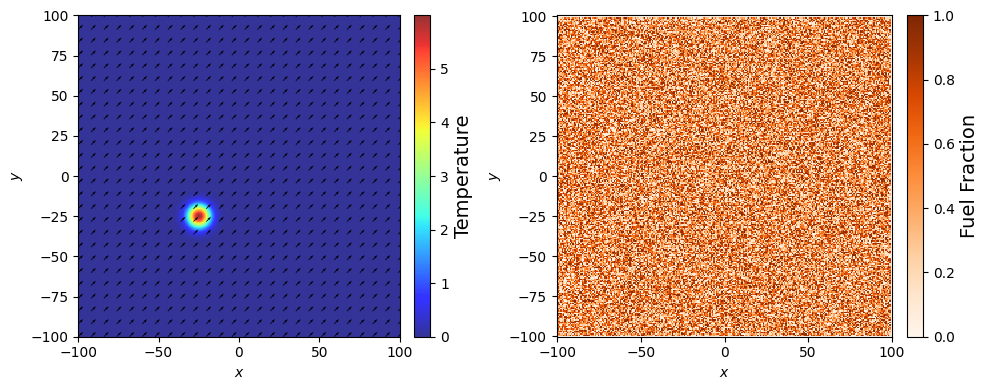

t:  3.75
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


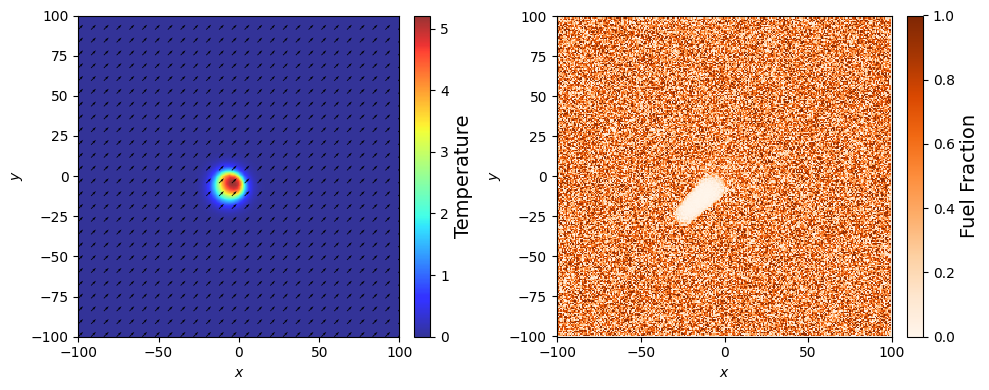

t:  7.5
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


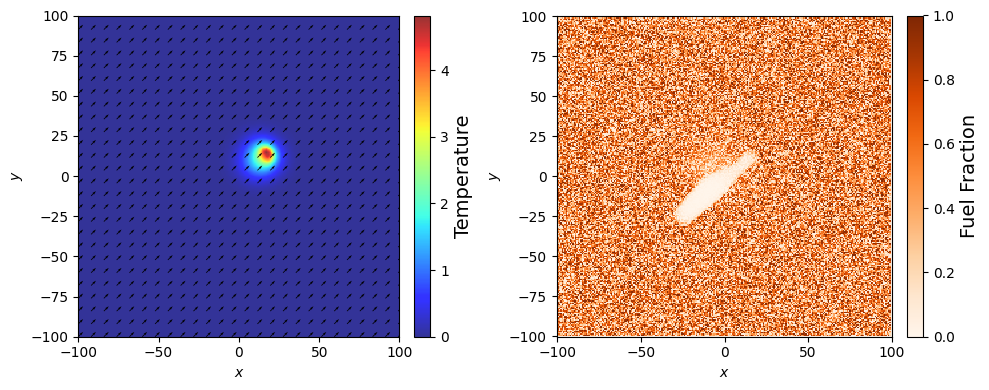

t:  11.25
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


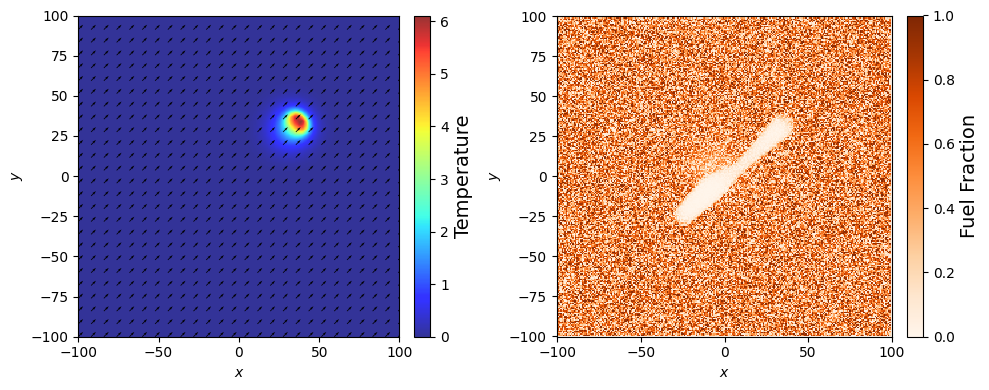

t:  15.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


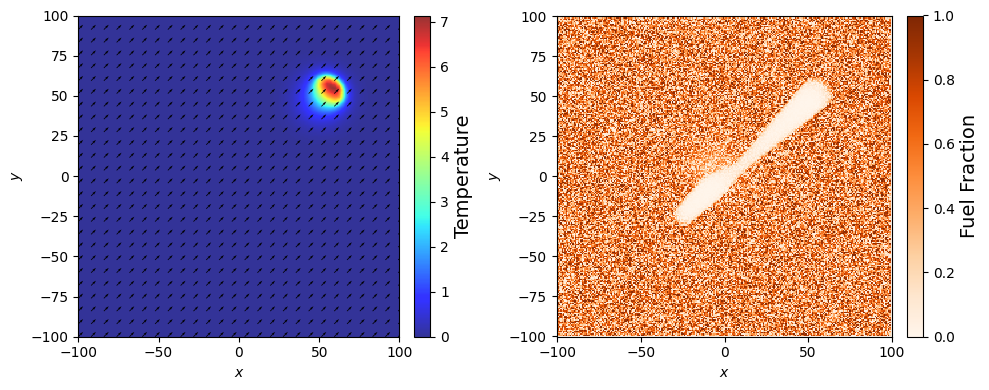

In [73]:
# example script for testing FD with controls

### PARAMETERS ###
# Model parameters #
kap = 1
eps = 3e-1
upc = 3.
alp = 1e-3
q = 1
x_min, x_max = -100, 100
y_min, y_max = -100, 100
t_min, t_max = 0, 15

# Numerical #
# Space
space_method = 'FD'
Nx = 252
Ny = 252
acc = 2
sparse = False

# Time
time_method = 'RK4'
Nt = 300
last = False

# Initial conditions
u0 = lambda x, y: 6 * G(x+25, y+25, 50)

# Fuel initial condition
def b0(x, y):
    np.random.seed(666)
    br = lambda x, y: np.round(np.random.uniform(size=(x.shape)), decimals=2)
    B = br(x, y)
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# Wind effect
gamma = 7
w1 = lambda x, y, t: gamma * np.cos(np.pi/4 + x * 0)
w2 = lambda x, y, t: gamma * np.sin(np.pi/4 + x * 0)
V = lambda x, y, t: (w1(x, y, t), w2(x, y, t))
### PARAMETERS ###

# Physical parameters for the model
physical_parameters = {    
    'kap': kap, # diffusion coefficient
    'eps': eps, # inverse of activation energy
    'upc': upc, # u phase change
    'q': q, # reaction heat
    'alp': alp, # natural convection,
    # Domain
    'x_lim': (x_min, x_max), # x-axis domain 
    'y_lim': (y_min, y_max), # y-axis domain
    't_lim': (t_min, t_max) # time domain
}

drop_1 = [0, 0, (3/4)*np.pi, 3]
drop_2 = [20, 20, (3/4)*np.pi, 6]
control_vars = np.asarray([drop_1])

# CONTROL PARAMETERS
control_params = {
    'v':5,
    'sigma_x':10,
    'sigma_y':10,
    'T':3,
    'k': 0.5,
    'delta': 0.2,
    'control_vars':control_vars
}

wildfire_ = wildfire.Fire(**physical_parameters, control_params=control_params)
t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b0, V, space_method, time_method, last=False, acc=acc, sparse=sparse)

# calculate and print Peclet and CFL numbers, according to following formulas
# peclet = (1 * Length) / diffusion const
# # set wind=1 for now.

## Plot results
if last:
    plots.UB(t, X, Y, U, B, V)
else:
    Ns = np.arange(Nt + 1)[::Nt // 4]
    for n in Ns:
        if (n%5==0):
            plots.UBs(n, t, X, Y, U, B, V)


Currently switched to upwind scheme (first order, forward and backward) for advection term to get more stability with lower time and spatial discretization requirements. 

Need to determine range of allowed 'k' values, for which solution will remain stable.

Need to add another term to Q/M such that waters action on temp doesn't make fuel or temp negative where fire is not present.

With too fine a spatial discretization, approximation diverges -> dx/dy can not be smaller than scale of sigmoid/gaussian control terms probably.

KeyboardInterrupt: 

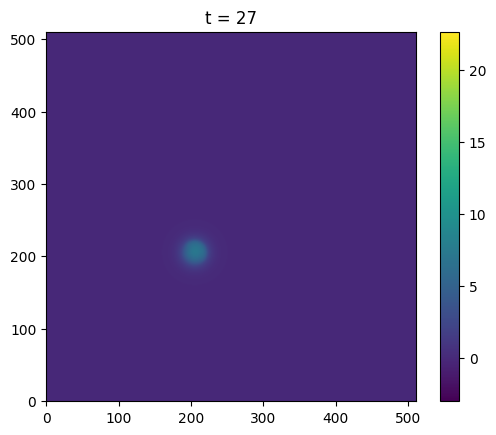

In [27]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# arr shape: (Nt, Nx, Ny)
arr = np.asarray(U)

fig, ax = plt.subplots()
im = ax.imshow(arr[0], origin='lower', vmin=arr.min(), vmax=arr.max(), animated=True)
ax.set_title("t = 0")
plt.colorbar(im, ax=ax)

def update(frame):
    im.set_array(arr[frame])
    ax.set_title(f"t = {frame}")
    return [im]

ani = FuncAnimation(fig, update, frames=arr.shape[0], interval=50, blit=True)

HTML(ani.to_jshtml())